# Langkah 1 - Ilustrasi Data Non-Linier

## Langkah 1a - Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

## Langkah 1b - Buat Kembali Fungsi Plotting



In [2]:
def plot_svc_decision_function(model, ax=None, plot_support=True):

  if ax is None:
      ax = plt.gca()
  xlim = ax.get_xlim()
  ylim = ax.get_ylim()
  
  x = np.linspace(xlim[0], xlim[1], 30)
  y = np.linspace(ylim[0], ylim[1], 30)
  Y, X = np.meshgrid(y, x)
  xy = np.vstack([X.ravel(), Y.ravel()]).T
  P = model.decision_function(xy).reshape(X.shape)
  
  ax.contour(X, Y, P, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
  
  if plot_support:
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=300, linewidth=1, facecolors='none');
  ax.set_xlim(xlim)
  ax.set_ylim(ylim)

## Langkah 1c - Buat Data Dummy Non-Linier



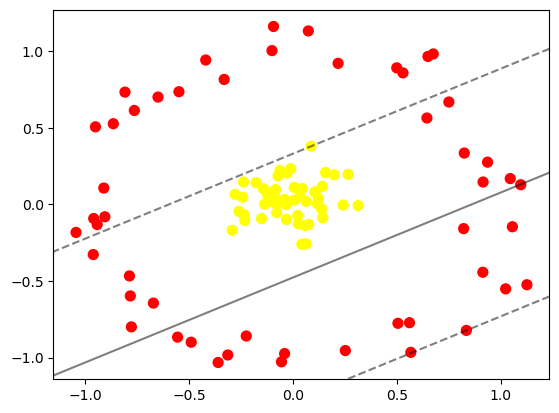

In [3]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [4]:
r = np.exp(-(X**2).sum(1))

In [5]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed	

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')	

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180), X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 2.17188709e-01,  9.21672229e-01],
       [ 4.99174214e-01,  8.92050721e-01],
       [-1.20375224e-01,  7.95998911e-02],
       [-4.19337195e-01,  9.43278322e-01],
       [ 9.14221336e-01,  1.46937807e-01],
       [-9.08956746e-02,  1.30151054e-02],
       [ 9.13063475e-01, -4.42314857e-01],
       [-8.07686718e-01,  7.33707243e-01],
       [ 2.65392719e-01,  1.96701189e-01],
       [ 1.12512510e+00, -5.24046285e-01],
       [-2.34221224e-01, -6.77441432e-02],
       [ 7.39832954e-02,  1.13321867e+00],
       [-9.60147310e-01, -3.26823503e-01],
       [-7.86177639e-01, -4.66504260e-01],
       [-1.03771168e-01,  7.37430621e-02],
       [-6.48811390e-01,  7.01472714e-01],
       [-9.57914592e-01, -9.15147560e-02],
       [ 5.04878188e-01, -7.75784498e-01],
       [-6.70997504e-01, -6.43788683e-01],
       [ 1.17221779e-01,  5.45497422e-03],
       [-9.04368591e-01, -8.02559326e-02],
       [-9.49581760e-01,  5.07130483e-01],
       

# Langkah 2 - Fitting Model


In [6]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

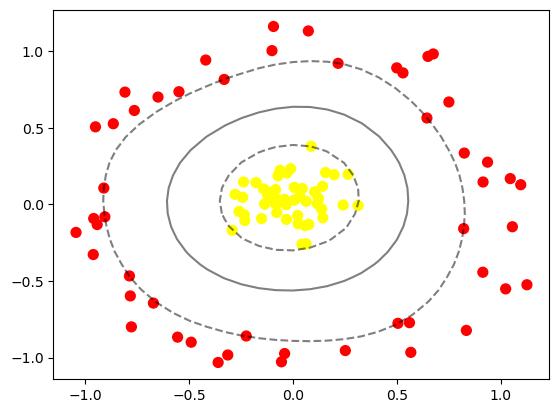

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=300, lw=1, facecolors='none')